# 批归一化 (Batch Normalization) 作用探究

本笔记本用于探究 Batch Normalization 在深度神经网络中的作用，特别是观察其如何维持网络各隐藏层特征方差的稳定。

- **Cell 1**: 环境准备与数据集加载
- **Cell 2**: 未添加 Normalization 的多层网络训练，记录每 Epoch 后各层特征方差并可视化
- **Cell 3**: 新增 Cell - 添加 Normalization (BatchNorm1d) 的网络训练，保持网络结构不变，同样记录每 Epoch 后各层特征方差并对比可视化

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)


plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(dataset=test_set, batch_size=256, shuffle=False)

print(f'训练集大小：{len(train_set)} 张')
print(f'测试集大小：{len(test_set)} 张')

训练集大小：60000 张
测试集大小：10000 张


=== 开始训练未添加 Normalization 的网络 ===
Epoch 1/5 | Loss: 0.8030 | 特征方差: Layer1=0.4899, Layer2=0.6577, Layer3=1.6562, Layer4=4.0202
epoch 1/5, train_loss: 0.8030, test_accuracy: 0.9426
Epoch 2/5 | Loss: 0.1584 | 特征方差: Layer1=0.4803, Layer2=0.5332, Layer3=1.4517, Layer4=4.0101
epoch 2/5, train_loss: 0.1584, test_accuracy: 0.9621
Epoch 3/5 | Loss: 0.1022 | 特征方差: Layer1=0.4995, Layer2=0.4985, Layer3=1.4574, Layer4=4.4315
epoch 3/5, train_loss: 0.1022, test_accuracy: 0.9613
Epoch 4/5 | Loss: 0.0731 | 特征方差: Layer1=0.4977, Layer2=0.4748, Layer3=1.3816, Layer4=4.3263
epoch 4/5, train_loss: 0.0731, test_accuracy: 0.9685
Epoch 5/5 | Loss: 0.0546 | 特征方差: Layer1=0.4977, Layer2=0.4626, Layer3=1.4378, Layer4=4.8601
epoch 5/5, train_loss: 0.0546, test_accuracy: 0.9742


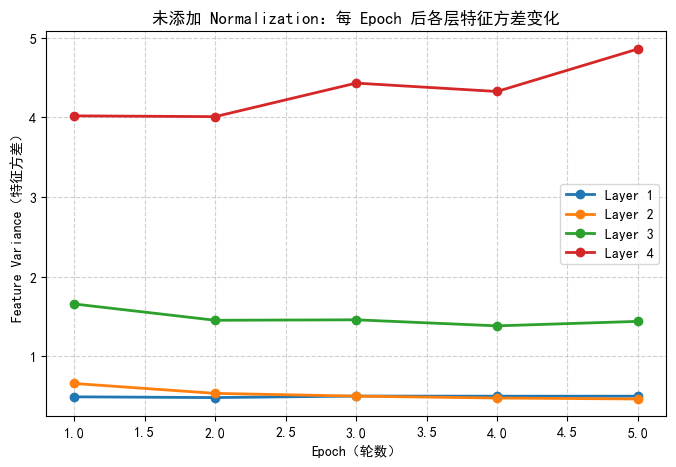

In [9]:
# === Cell 2: 无 Normalization 的网络训练与特征方差统计 ===

class DeepMLP_NoBN(nn.Module):
    def __init__(self):
        super(DeepMLP_NoBN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 10)

    def forward_features(self, x):
        x = x.view(-1, 784)
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        h3 = F.relu(self.fc3(h2))
        h4 = F.relu(self.fc4(h3))
        out = self.fc5(h4)
        return out, [h1, h2, h3, h4]

    def forward(self, x):
        x = x.view(-1, 784)
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        h3 = F.relu(self.fc3(h2))
        h4 = F.relu(self.fc4(h3))
        out = self.fc5(h4)
        return out

def get_layer_variances(model, data_loader):
    """计算各隐藏层特征在整个测试集上的方差"""
    model.eval()
    layer_feats = [[] for _ in range(4)]
    with torch.no_grad():
        for xb, _ in data_loader:
            _, feats = model.forward_features(xb)
            for i, f in enumerate(feats):
                layer_feats[i].append(f)
    # 计算各个隐藏层的全特征方差
    variances = [torch.cat(feats_list, dim=0).var().item() for feats_list in layer_feats]
    return variances

# 初始化无 BN 的模型及优化器
torch.manual_seed(42)
model_nobn = DeepMLP_NoBN()
optimizer_nobn = optim.SGD(model_nobn.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

# 记录无 BN 网络每 epoch 后各层的特征方差
variances_nobn_history = []
epochs = 5

print("=== 开始训练未添加 Normalization 的网络 ===")
for epoch in range(epochs):
    model_nobn.train()
    running_loss = 0.0
    n_samples = 0
    for xb, yb in train_loader:
        optimizer_nobn.zero_grad()
        logits, _ = model_nobn.forward_features(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer_nobn.step()
        running_loss += loss.item() * yb.size(0)
        n_samples += yb.size(0)

    # 统计本 Epoch 结束后每层特征的方差
    vars_epoch = get_layer_variances(model_nobn, test_loader)
    variances_nobn_history.append(vars_epoch)
    
    model_nobn.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model_nobn(xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()

    train_losses_v2, test_losses_v2 = [], []  # 记录训练集和测试集的损失
    train_losses_v2.append(running_loss / n_samples)
    test_losses_v2.append(correct / len(test_set))

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_set):.4f} | "
          f"特征方差: Layer1={vars_epoch[0]:.4f}, Layer2={vars_epoch[1]:.4f}, Layer3={vars_epoch[2]:.4f}, Layer4={vars_epoch[3]:.4f}")
    print(f'epoch {epoch+1}/5, train_loss: {train_losses_v2[-1]:.4f}, test_accuracy: {test_losses_v2[-1]:.4f}')

# 绘制未添加 Normalization 时各层特征方差曲线
plt.figure(figsize=(8, 5))
for layer_idx in range(4):
    vars_layer = [epoch_vars[layer_idx] for epoch_vars in variances_nobn_history]
    plt.plot(range(1, epochs + 1), vars_layer, marker='o', linewidth=2, label=f'Layer {layer_idx+1}')

plt.xlabel('Epoch（轮数）')
plt.ylabel('Feature Variance（特征方差）')
plt.title('未添加 Normalization：每 Epoch 后各层特征方差变化')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

=== 开始训练添加了 Batch Normalization 的网络 ===
Epoch 1/5 | Loss: 0.2657 | 特征方差: Layer1=0.3627, Layer2=0.3797, Layer3=0.4077, Layer4=0.9081
epoch 1/5, train_loss: 1.5945, test_accuracy: 0.9691
Epoch 2/5 | Loss: 0.0876 | 特征方差: Layer1=0.3460, Layer2=0.3652, Layer3=0.4004, Layer4=1.0159
epoch 2/5, train_loss: 0.5254, test_accuracy: 0.9733
Epoch 3/5 | Loss: 0.0582 | 特征方差: Layer1=0.3500, Layer2=0.3719, Layer3=0.4079, Layer4=1.0746
epoch 3/5, train_loss: 0.3494, test_accuracy: 0.9766
Epoch 4/5 | Loss: 0.0431 | 特征方差: Layer1=0.3348, Layer2=0.3468, Layer3=0.3767, Layer4=1.0424
epoch 4/5, train_loss: 0.2584, test_accuracy: 0.9768
Epoch 5/5 | Loss: 0.0315 | 特征方差: Layer1=0.3362, Layer2=0.3646, Layer3=0.4046, Layer4=1.1699
epoch 5/5, train_loss: 0.1893, test_accuracy: 0.9811


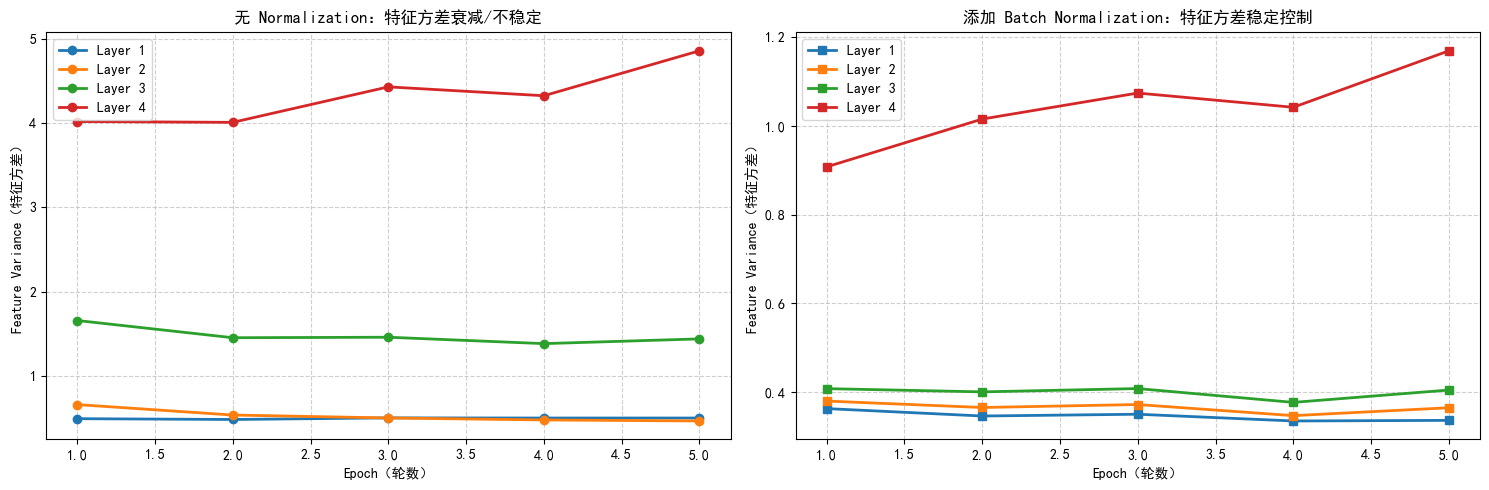

In [11]:
# === Cell 3: 新增 Cell - 添加 Normalization (BatchNorm1d) 的网络训练与特征方差统计 ===

class DeepMLP_WithBN(nn.Module):
    def __init__(self):
        super(DeepMLP_WithBN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.fc5 = nn.Linear(32, 10)

    def forward_features(self, x):
        x = x.view(-1, 784)
        h1 = F.relu(self.bn1(self.fc1(x)))
        h2 = F.relu(self.bn2(self.fc2(h1)))
        h3 = F.relu(self.bn3(self.fc3(h2)))
        h4 = F.relu(self.bn4(self.fc4(h3)))
        out = self.fc5(h4)
        return out, [h1, h2, h3, h4]

    def forward(self, x):
        x = x.view(-1, 784)
        h1 = F.relu(self.bn1(self.fc1(x)))
        h2 = F.relu(self.bn2(self.fc2(h1)))
        h3 = F.relu(self.bn3(self.fc3(h2)))
        h4 = F.relu(self.bn4(self.fc4(h3)))
        out = self.fc5(h4)
        return out

# 初始化添加了 BN 的模型及优化器（其他超参数和随机种子与无 BN 网络完全一致）
torch.manual_seed(42)
model_bn = DeepMLP_WithBN()
optimizer_bn = optim.SGD(model_bn.parameters(), lr=0.1)

# 记录含 BN 网络每 epoch 后各层的特征方差
variances_bn_history = []

print("=== 开始训练添加了 Batch Normalization 的网络 ===")
for epoch in range(epochs):
    model_bn.train()
    running_loss = 0.0
    n_samples = 0
    for xb, yb in train_loader:
        optimizer_bn.zero_grad()
        logits, _ = model_bn.forward_features(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer_bn.step()
        running_loss += loss.item() * yb.size(0)

    # 统计本 Epoch 结束后每层特征的方差
    vars_epoch = get_layer_variances(model_bn, test_loader)
    variances_bn_history.append(vars_epoch)
    
    model_bn.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model_bn(xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            n_samples += yb.size(0)

    train_losses_v2, test_losses_v2 = [], []  # 记录训练集和测试集的损失
    train_losses_v2.append(running_loss / n_samples)
    test_losses_v2.append(correct / len(test_set))

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_set):.4f} | "
          f"特征方差: Layer1={vars_epoch[0]:.4f}, Layer2={vars_epoch[1]:.4f}, Layer3={vars_epoch[2]:.4f}, Layer4={vars_epoch[3]:.4f}")
    print(f'epoch {epoch+1}/5, train_loss: {train_losses_v2[-1]:.4f}, test_accuracy: {test_losses_v2[-1]:.4f}')
    
# 对比可视化：无 Normalization vs 添加 Batch Normalization 的每层特征方差对比
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 无 Normalization 对比图
for layer_idx in range(4):
    vars_layer = [epoch_vars[layer_idx] for epoch_vars in variances_nobn_history]
    axes[0].plot(range(1, epochs + 1), vars_layer, marker='o', linewidth=2, label=f'Layer {layer_idx+1}')
axes[0].set_xlabel('Epoch（轮数）')
axes[0].set_ylabel('Feature Variance（特征方差）')
axes[0].set_title('无 Normalization：特征方差衰减/不稳定')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 添加 Batch Normalization 对比图
for layer_idx in range(4):
    vars_layer = [epoch_vars[layer_idx] for epoch_vars in variances_bn_history]
    axes[1].plot(range(1, epochs + 1), vars_layer, marker='s', linewidth=2, label=f'Layer {layer_idx+1}')
axes[1].set_xlabel('Epoch（轮数）')
axes[1].set_ylabel('Feature Variance（特征方差）')
axes[1].set_title('添加 Batch Normalization：特征方差稳定控制')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
"""
MNIST 手写识别 — PyTorch CNN 实现
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time
import os

# ==================== 超参数 ====================
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 10

# ==================== 数据加载 ====================
transform = transforms.Compose([
    transforms.ToTensor(),                                # 0~255 → 0~1, 且转为 (C,H,W)
    transforms.Normalize((0.1307,), (0.3081,))            # MNIST 全局均值/标准差归一化
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


# ==================== 网络定义 ====================
class CNN(nn.Module):
    """
    结构: Conv → ReLU → Pool → Conv → ReLU → Pool → Flatten → FC → ReLU → FC → Softmax

    为什么 conv 后必须接 flatten + FC + softmax?
    ─────────────────────────────────────────────
    Conv 层: 提取局部特征 (边缘、纹理、形状)，输出是特征图 (C, H', W')
            每个位置的值表示"该位置有某种模式"的响应强度。
            但它输出的仍然是"空间分布"，不是"概率"。

    Flatten:  把 (C, H', W') 拉直成一维向量 (C*H'*W',)
              打破空间结构，让 FC 层可以"全局看"所有特征。

    FC 层:    将提取到的所有特征加权组合，映射到类别得分。
             FC1 做特征融合，FC2 输出 10 个类别的原始分数 (logits)。

    Softmax:  将 10 个分数转为概率分布 (加起来 = 1)，取最大值索引即为预测类别。
    """
    def __init__(self):
        super(CNN, self).__init__()
        # 特征提取器 (Conv + Pool)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)  # 1→8, 28→28
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1) # 8→16, 14→14 (pool后)
        # 分类器 (FC)
        self.fc1 = nn.Linear(16 * 7 * 7, 64)   # pool2 后特征图: 16×7×7
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # x: (N, 1, 28, 28)

        # --- 特征提取 (Conv + Pool) ---
        x = self.conv1(x)           # (N, 8, 28, 28)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)      # (N, 8, 14, 14)

        x = self.conv2(x)           # (N, 16, 14, 14)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)      # (N, 16, 7, 7)

        # --- 分类 (Flatten + FC + Softmax) ---
        x = x.view(x.size(0), -1)   # Flatten: (N, 16*7*7)
        x = self.fc1(x)             # (N, 64)
        x = F.relu(x)
        x = self.fc2(x)             # (N, 10)  ← logits
        # CrossEntropyLoss 内部自带 Softmax, 所以 forward 不用显式调用
        return x


# ==================== 训练 ====================
device = torch.device('cpu')
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()           # 内置 Softmax + NLLLoss
optimizer = optim.Adam(model.parameters(), lr=LR)


def train():
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        start = time.time()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        elapsed = time.time() - start
        print(f'Epoch {epoch+1:2d}/{EPOCHS}  loss: {avg_loss:.6f}  ({elapsed:.1f}s)')


# ==================== 评估 ====================
def evaluate():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100.0 * correct / total
    print(f'Test accuracy: {acc:.2f}%')
    return acc


# ==================== 运行 ====================
if __name__ == '__main__':
    train()
    evaluate()

    # 保存模型
    torch.save(model.state_dict(), 'mnist_cnn.pth')
    print('Model saved to mnist_cnn.pth')


Epoch  1/10  loss: 0.226498  (20.9s)
Epoch  2/10  loss: 0.071306  (20.6s)
Epoch  3/10  loss: 0.051183  (21.0s)
Epoch  4/10  loss: 0.042079  (20.5s)
Epoch  5/10  loss: 0.033950  (20.4s)
Epoch  6/10  loss: 0.027530  (20.9s)
Epoch  7/10  loss: 0.024468  (23.7s)
Epoch  8/10  loss: 0.020637  (22.1s)
Epoch  9/10  loss: 0.018637  (23.3s)
Epoch 10/10  loss: 0.014995  (23.9s)
Test accuracy: 98.85%
Model saved to mnist_cnn.pth


In [13]:
from IPython.display import display
from ipycanvas import Canvas
from ipywidgets import Button, HBox, VBox, Output
from PIL import Image

# 画板设置
CANVAS_SIZE= 560
LINE_WIDTH = max(8, CANVAS_SIZE // 14)  # 根据画板宽度动态设置线条宽度

canvas = Canvas(width=CANVAS_SIZE, height=CANVAS_SIZE, sync_image_data=True)
canvas.layout.width = f'{CANVAS_SIZE}px'
canvas.layout.height = f'{CANVAS_SIZE}px'
canvas.fill_style = 'black'
canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)  # 黑色背景
canvas.stroke_style = 'white'
canvas.line_width = LINE_WIDTH

brush = {'down': False, 'last': None}

def on_mouse_down(x, y):
    brush['down'] = True
    brush['last'] = (x, y)

def on_mouse_move(x, y):
    if brush['down'] and brush['last'] is not None:
        canvas.stroke_line(brush['last'][0], brush['last'][1], x, y)
        brush['last'] = (x, y)

def on_mouse_up(x, y):
    brush['down'] = False
    brush['last'] = None

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

output = Output()
btn_predict = Button(description='识别', button_style='primary', icon='check')
btn_clear = Button(description='清空', icon='trash')

def predict(_):
    output.clear_output()

    arr = canvas.get_image_data()
    if arr is None:
        with output:
            print('画板还没准备好，等 1 秒再试，或者现在画板上随便画一笔')
        return
    img = Image.fromarray(arr).convert('L')
    img = img.resize((28, 28), Image.LANCZOS)
    arr28 = np.array(img, dtype=np.float32)/255.0

    x = (torch.from_numpy(arr28) - 0.1307) / 0.3081

    model_bn.eval()
    with torch.no_grad():
        logits = model_bn(x.unsqueeze(0))  # 增加 batch 维度
        probs = F.softmax(logits, dim=1)[0].numpy()
    pred = int(probs.argmax())

    with output:
        fig, ax = plt.subplots(1, 2, figsize=(9, 3))
        ax[0].imshow(arr28, cmap='gray')
        ax[0].set_title('模型看到的（28 × 28）', fontsize=12)
        ax[0].axis('off')
        ax[1].bar(range(10), probs,
                  color=['coral' if i == pred else 'lightsteelblue' for i in range(10)])
        ax[1].set_xticks(range(10))
        ax[1].set_xlabel('类别')
        ax[1].set_ylim(0, 1)
        ax[1].set_title(f'模型预测 {pred}，置信度 {probs[pred]:.1%}', fontsize=12)
        ax[1].grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

def clear_canvas(_):
    canvas.clear()
    canvas.fill_style = 'black'
    canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
    output.clear_output()

btn_predict.on_click(predict)
btn_clear.on_click(clear_canvas)

container = VBox(
    [canvas, HBox([btn_predict, btn_clear]), output],
    layout={'width': f'{CANVAS_SIZE+20}px', 'align_items': 'flex-start'},
    )
display(container)

In [ ]:
from IPython.display import display
from ipycanvas import Canvas
from ipywidgets import Button, HBox, VBox, Output
from PIL import Image

# 画板设置
CANVAS_SIZE= 560
LINE_WIDTH = max(8, CANVAS_SIZE // 14)  # 根据画板宽度动态设置线条宽度

canvas = Canvas(width=CANVAS_SIZE, height=CANVAS_SIZE, sync_image_data=True)
canvas.layout.width = f'{CANVAS_SIZE}px'
canvas.layout.height = f'{CANVAS_SIZE}px'
canvas.fill_style = 'black'
canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)  # 黑色背景
canvas.stroke_style = 'white'
canvas.line_width = LINE_WIDTH

brush = {'down': False, 'last': None}

def on_mouse_down(x, y):
    brush['down'] = True
    brush['last'] = (x, y)

def on_mouse_move(x, y):
    if brush['down'] and brush['last'] is not None:
        canvas.stroke_line(brush['last'][0], brush['last'][1], x, y)
        brush['last'] = (x, y)

def on_mouse_up(x, y):
    brush['down'] = False
    brush['last'] = None

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

output = Output()
btn_predict = Button(description='识别', button_style='primary', icon='check')
btn_clear = Button(description='清空', icon='trash')

def predict(_):
    output.clear_output()

    arr = canvas.get_image_data()
    if arr is None:
        with output:
            print('画板还没准备好，等 1 秒再试，或者现在画板上随便画一笔')
        return
    img = Image.fromarray(arr).convert('L')
    img = img.resize((28, 28), Image.LANCZOS)
    arr28 = np.array(img, dtype=np.float32)/255.0

    x = (torch.from_numpy(arr28) - 0.1307) / 0.3081

    model.eval()
    with torch.no_grad():
        logits = model(x.view(1, 1, 28, 28)) #调整为4维：(batch=1, channel=1, height=28, width=28)
        probs = F.softmax(logits, dim=1)[0].numpy()
    pred = int(probs.argmax())

    with output:
        fig, ax = plt.subplots(1, 2, figsize=(9, 3))
        ax[0].imshow(arr28, cmap='gray')
        ax[0].set_title('模型看到的（28 × 28）', fontsize=12)
        ax[0].axis('off')
        ax[1].bar(range(10), probs,
                  color=['coral' if i == pred else 'lightsteelblue' for i in range(10)])
        ax[1].set_xticks(range(10))
        ax[1].set_xlabel('类别')
        ax[1].set_ylim(0, 1)
        ax[1].set_title(f'模型预测 {pred}，置信度 {probs[pred]:.1%}', fontsize=12)
        ax[1].grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

def clear_canvas(_):
    canvas.clear()
    canvas.fill_style = 'black'
    canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
    output.clear_output()

btn_predict.on_click(predict)
btn_clear.on_click(clear_canvas)

container = VBox(
    [canvas, HBox([btn_predict, btn_clear]), output],
    layout={'width': f'{CANVAS_SIZE+20}px', 'align_items': 'flex-start'},
    )
display(container)